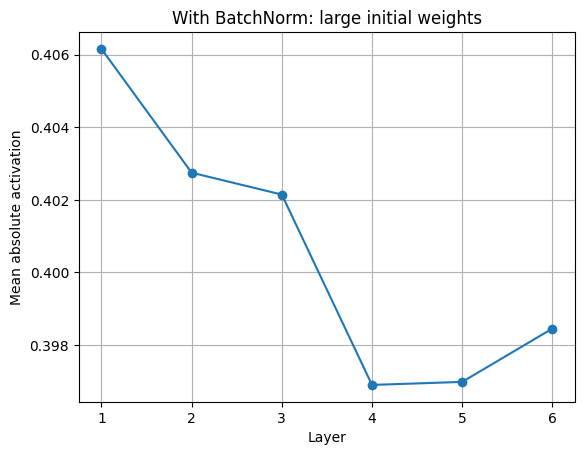

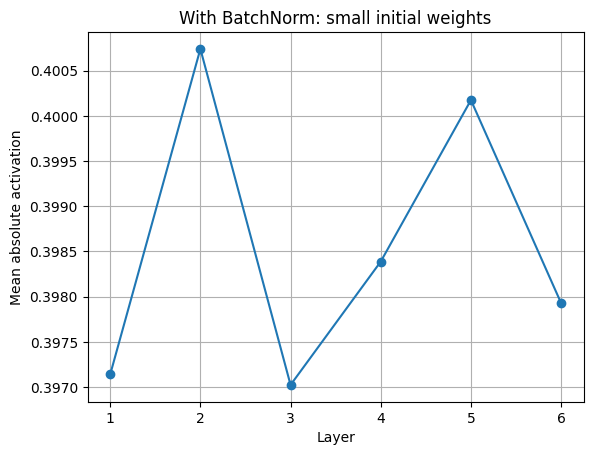

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

def build_model(weight_scale, use_batchnorm=False):
    layers = []

    for _ in range(6):
        linear = nn.Linear(64, 64)

        with torch.no_grad():
            linear.weight *= weight_scale
            linear.bias *= weight_scale

        layers.append(linear)

        if use_batchnorm:
            layers.append(nn.BatchNorm1d(64))

        layers.append(nn.ReLU())

    return nn.Sequential(*layers)


def collect_activations(model, x):
    values = []
    h = x

    model.train()  # BatchNorm utilise les stats du batch

    with torch.no_grad():
        for layer in model:
            h = layer(h)
            if isinstance(layer, nn.ReLU):
                values.append(h.abs().mean().item())

    return values


# Batch size > 1 obligatoire pour BatchNorm en mode train
x = torch.randn(32, 64)

exploding_bn_model = build_model(weight_scale=3.0, use_batchnorm=True)
collapsing_bn_model = build_model(weight_scale=0.2, use_batchnorm=True)

exploding_bn_values = collect_activations(exploding_bn_model, x)
collapsing_bn_values = collect_activations(collapsing_bn_model, x)

layers = range(1, len(exploding_bn_values) + 1)

plt.figure()
plt.plot(layers, exploding_bn_values, marker="o")
plt.xlabel("Layer")
plt.ylabel("Mean absolute activation")
plt.title("With BatchNorm: large initial weights")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(layers, collapsing_bn_values, marker="o")
plt.xlabel("Layer")
plt.ylabel("Mean absolute activation")
plt.title("With BatchNorm: small initial weights")
plt.grid(True)
plt.show()

Exploding: [6.1191086769104, 42.85082244873047, 308.1474609375, 2071.7060546875, 14303.6826171875, 110338.078125]
Collapsing: [0.0392640084028244, 0.0023334845900535583, 0.00013251675409264863, 5.896084985579364e-06, 3.237296084535046e-07, 1.7366271976015923e-08]


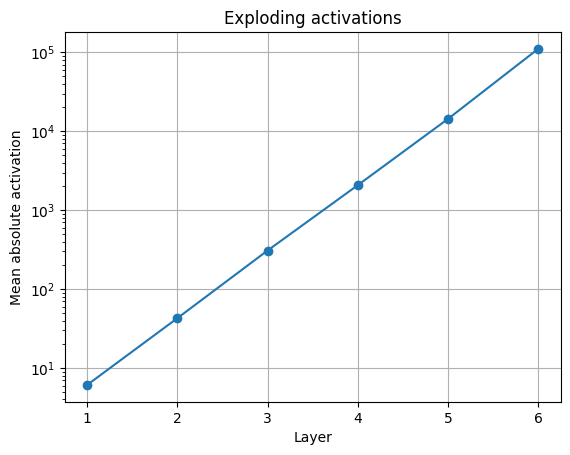

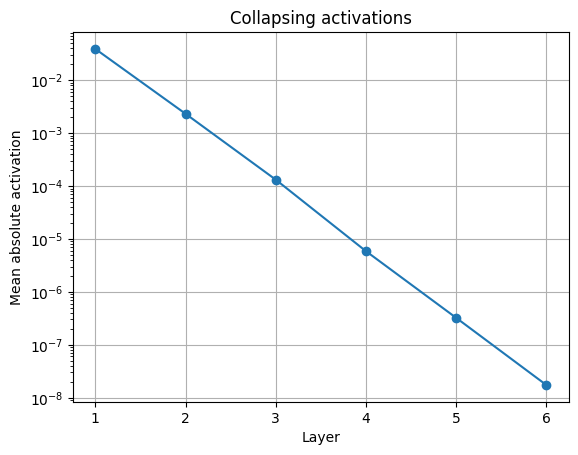

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

def build_model(weight_std):
    layers = []
    for _ in range(6):
        layer = nn.Linear(64, 64)

        with torch.no_grad():
            layer.weight.normal_(mean=0.0, std=weight_std)
            layer.bias.zero_()

        layers += [layer, nn.ReLU()]

    return nn.Sequential(*layers)


def collect_activations(model, x):
    values = []
    h = x

    with torch.no_grad():
        for layer in model:
            h = layer(h)
            if isinstance(layer, nn.ReLU):
                values.append(h.abs().mean().item())

    return values


x = torch.randn(1, 64)

exploding_model = build_model(weight_std=1.5)
collapsing_model = build_model(weight_std=0.01)

exploding_values = collect_activations(exploding_model, x)
collapsing_values = collect_activations(collapsing_model, x)

print("Exploding:", exploding_values)
print("Collapsing:", collapsing_values)

layers = range(1, 7)

plt.figure()
plt.plot(layers, exploding_values, marker="o")
plt.yscale("log")
plt.xlabel("Layer")
plt.ylabel("Mean absolute activation")
plt.title("Exploding activations")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(layers, collapsing_values, marker="o")
plt.yscale("log")
plt.xlabel("Layer")
plt.ylabel("Mean absolute activation")
plt.title("Collapsing activations")
plt.grid(True)
plt.show()